# Diabetic Retinopathy — Dual-Track Ensemble Notebook

**Tracks implemented in this notebook:**
| Track | Architecture | Pretrained | Output |
|-------|-------------|-----------|--------|
| **Custom** | `custom_vggx3` | ✗ | `output_custom.csv` |
| **Fine-tune** | `EfficientNet-B2` + `DenseNet-121` + `TinyViT-21M` | ✓ | `output_ft.csv` |

**Metric:** AUC (area under the ROC curve)  
**Submission:** `results/outputs/c{AUC_custom}_ft{AUC_ft}_{date}.zip`

---
## Pipeline overview
```
data/train.csv + images/
     │
     ▼
RetinopathyDataset  ──  right-eye mirror · CLAHE · intensity-scaled augmentations
WeightedRandomSampler  ──  balance DR vs No-DR
     │
     ├── [CustomConfig]   EnsembleModel(['custom_vgg','custom_vgg','custom_vgg'], pretrained=False)
     │                         └── Trainer (BCEWithLogitsLoss on member logits)
     │
     └── [FineTuneConfig] EnsembleModel(['efficientnet_b2','densenet121','tiny_vit_21m_...'], pretrained=True)
                               └── Trainer (BCELoss on averaged probabilities)
                                         ▼
                               results/outputs/{custom,ft}.csv
                               results/c{AUC}_ft{AUC}_{date}.zip
```

---
## 0 · Imports & reproducibility

In [1]:
%matplotlib inline
from __future__ import print_function, division

import os, random, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics

import torch
import torch.nn as nn

warnings.filterwarnings('ignore')

# ── Project imports ──────────────────────────────────────────────────────────
from utils.config import Config, CustomConfig, FineTuneConfig
from utils.data_processing import (
    RetinopathyDataset, get_dataloader, apply_clahe_green,
    build_train_transforms, build_eval_transforms, build_tta_transforms,
)
from utils.data_processing import apply_clahe_green

from src.model import BaseModel, EnsembleModel
from src.model_components import Custom_VGG
from utils.trainer import Trainer

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = Config.seed
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

print(f'Device  : {Config.device}')
print(f'PyTorch : {torch.__version__}')
print(f'Seed    : {SEED}')

Device  : cuda
PyTorch : 2.10.0+cu128
Seed    : 42


---
## 1 · Exploratory Data Analysis (EDA)

In [2]:
# ── Load split CSVs ──────────────────────────────────────────────────────────
cfg = Config

train_df = pd.read_csv(cfg.train_csv, dtype={'id': str, 'eye': int, 'label': int})
val_df   = pd.read_csv(cfg.val_csv,   dtype={'id': str, 'eye': int, 'label': int})
test_df  = pd.read_csv(cfg.test_csv,  dtype={'id': str, 'eye': int, 'label': int})

print(f'Train : {len(train_df):>5,} samples')
print(f'Val   : {len(val_df):>5,} samples')
print(f'Test  : {len(test_df):>5,} samples')
train_df.head()

Train : 2,000 samples
Val   :   500 samples
Test  : 1,000 samples


,id,eye,label
0,00000,0,0
1,00001,1,0
2,00002,1,2
3,00003,1,0
4,00004,0,0


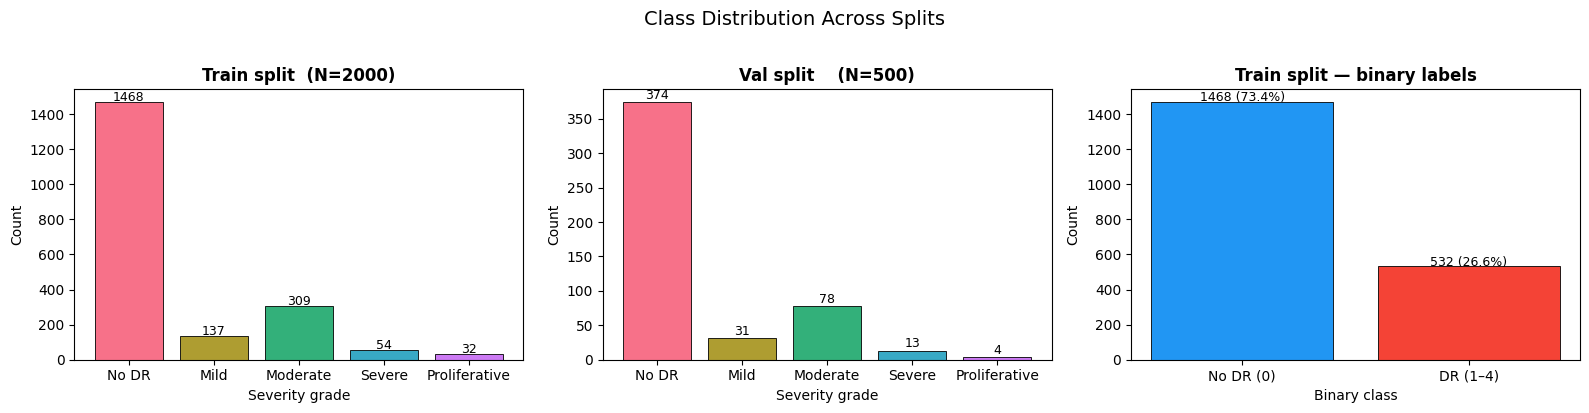

Class imbalance ratio  No-DR : DR = 0.73 : 0.27
Implied pos_weight            = 2.759


In [3]:
# ─── Class distribution ───────────────────────────────────────────────────────
severity_labels = {0: 'No DR', 1: 'Mild', 2: 'Moderate', 3: 'Severe', 4: 'Proliferative'}
binary_labels   = {0: 'No DR (0)', 1: 'DR (1–4)'}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
palette   = sns.color_palette('husl', 5)

for ax, (df, title) in zip(axes, [
    (train_df, 'Train split  (N=2000)'),
    (val_df,   'Val split    (N=500)'),
]):
    counts = df['label'].value_counts().sort_index()
    ax.bar([severity_labels[i] for i in counts.index], counts.values,
           color=palette[:len(counts)], edgecolor='k', linewidth=0.6)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Severity grade')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 5, str(v), ha='center', fontsize=9)

# Binary view
ax = axes[2]
binary_counts = (train_df['label'] > 0).value_counts().sort_index()
ax.bar([binary_labels[i] for i in binary_counts.index], binary_counts.values,
       color=['#2196F3', '#F44336'], edgecolor='k', linewidth=0.6)
ax.set_title('Train split — binary labels', fontsize=12, fontweight='bold')
ax.set_xlabel('Binary class')
ax.set_ylabel('Count')
for i, v in enumerate(binary_counts.values):
    ax.text(i, v + 5, f'{v} ({100*v/len(train_df):.1f}%)', ha='center', fontsize=9)

plt.suptitle('Class Distribution Across Splits', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

pos_frac = (train_df['label'] > 0).mean()
print(f'Class imbalance ratio  No-DR : DR = {1-pos_frac:.2f} : {pos_frac:.2f}')
print(f'Implied pos_weight            = {(1-pos_frac)/pos_frac:.3f}')

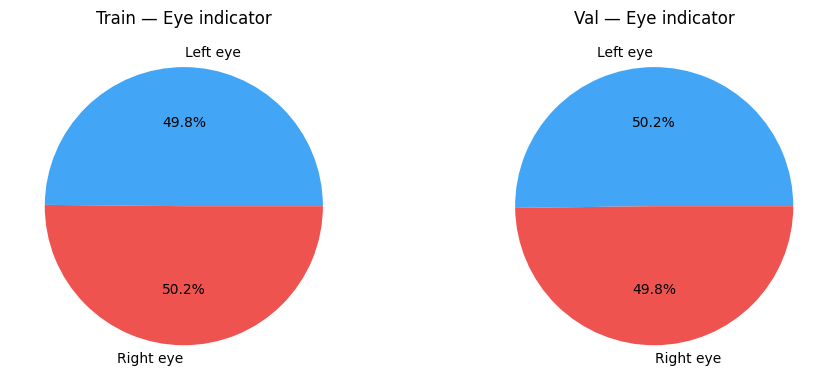

In [4]:
# ─── Eye indicator distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (df, title) in zip(axes, [
    (train_df, 'Train'),
    (val_df,   'Val'),
]):
    counts = df['eye'].value_counts().sort_index()
    ax.pie(counts.values, labels=['Left eye', 'Right eye'],
           autopct='%1.1f%%', colors=['#42A5F5', '#EF5350'])
    ax.set_title(f'{title} — Eye indicator')

plt.tight_layout()
plt.show()

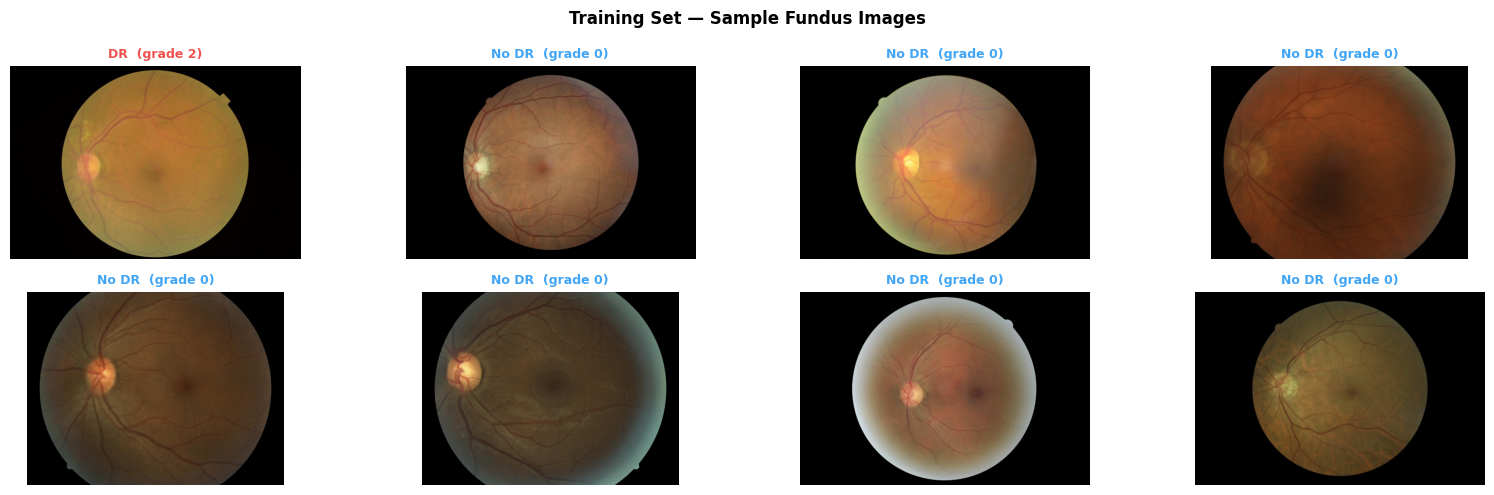

In [5]:
# ── Visualise sample fundus images ───────────────────────────────────────────
import skimage.io as skio
import skimage.util as skutil

IMG_DIR = Config.images_dir

def show_samples(df, title, n=8):
    """Show n random fundus images from a DataFrame split."""
    sample = df.sample(n, random_state=SEED).reset_index(drop=True)
    fig, axes = plt.subplots(2, n//2, figsize=(16, 5))
    axes = axes.flatten()
    for i, (_, row) in enumerate(sample.iterrows()):
        path = os.path.join(IMG_DIR, row['id'] + '.jpg')
        if not os.path.exists(path):
            axes[i].text(0.5, 0.5, 'Image\nnot found', ha='center', va='center',
                         transform=axes[i].transAxes, fontsize=9, color='grey')
            axes[i].set_xticks([]); axes[i].set_yticks([])
            continue
        img = skio.imread(path)
        if row['eye'] == 1:
            img = img[:, ::-1, :]
        axes[i].imshow(img)
        label_str = 'DR' if row['label'] > 0 else 'No DR'
        color     = '#EF5350' if row['label'] > 0 else '#42A5F5'
        axes[i].set_title(f'{label_str}  (grade {row["label"]})',
                          color=color, fontsize=9, fontweight='bold')
        axes[i].axis('off')
    fig.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_samples(train_df, 'Training Set — Sample Fundus Images', n=8)

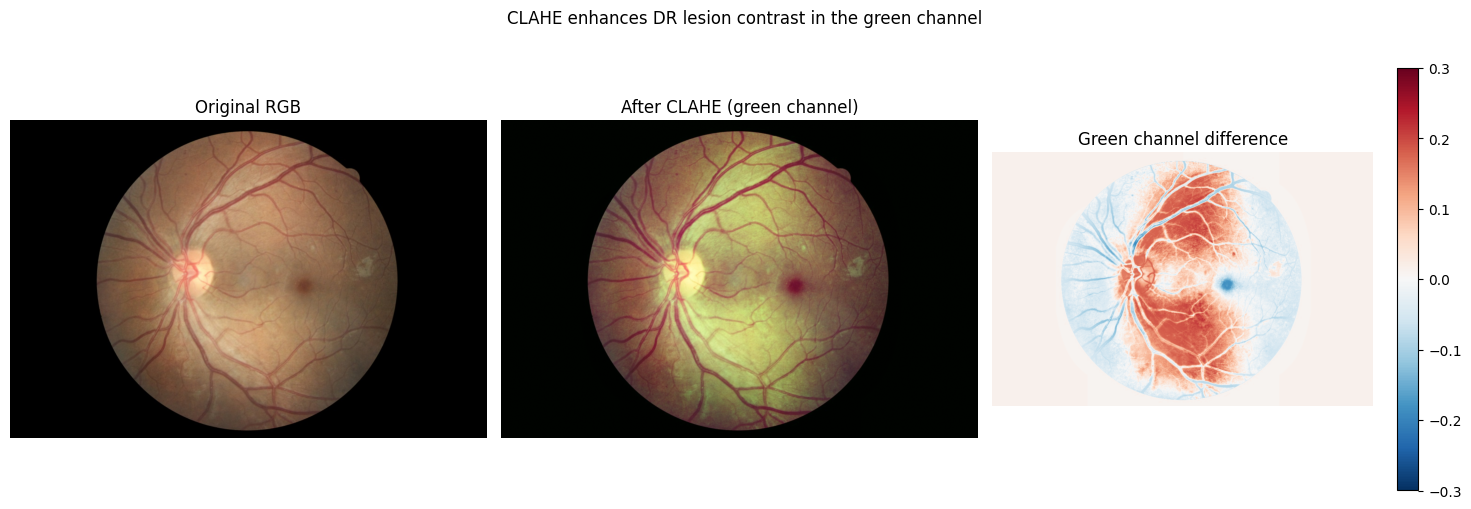

In [6]:
# ─── CLAHE effect visualisation ───────────────────────────────────────────────
row = train_df[train_df['label'] > 0].sample(1, random_state=1).iloc[0]
img = skutil.img_as_float(skio.imread(os.path.join(cfg.images_dir, row['id'] + '.jpg')))
img_clahe = apply_clahe_green(img)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img)
axes[0].set_title('Original RGB')
axes[1].imshow(img_clahe)
axes[1].set_title('After CLAHE (green channel)')
# Difference map on green channel
diff = img_clahe[:,:,1].astype(float) - img[:,:,1].astype(float)
im = axes[2].imshow(diff, cmap='RdBu_r', vmin=-0.3, vmax=0.3)
axes[2].set_title('Green channel difference')
plt.colorbar(im, ax=axes[2])
for ax in axes:
    ax.axis('off')
plt.suptitle('CLAHE enhances DR lesion contrast in the green channel',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## 2 · Track A — Custom VGG Ensemble (from scratch)

**Architecture:** `Custom_VGG × 3` — *no pretrained weights*  
**Key difference from fine-tuning:** all parameters are randomly initialised;
higher learning rate, stronger augmentation, and longer patience are used.

In [7]:
# ── Config summary ────────────────────────────────────────────────────────────
custom_cfg = CustomConfig

print('='*55)
print('  CUSTOM TRACK — CONFIG')
print('='*55)
for attr in ['pretrained','aug_intensity','unfreeze_layers','num_epochs',
             'learning_rate','weight_decay','early_stopping','batch_size',
             'aug_rigid','aug_regularize','aug_clahe']:
    print(f'  {attr:<20} : {getattr(custom_cfg, attr)}')
print('='*55)

  CUSTOM TRACK — CONFIG
  pretrained           : False
  aug_intensity        : 0.9
  unfreeze_layers      : -1
  num_epochs           : 60
  learning_rate        : 0.0005
  weight_decay         : 0.0005
  early_stopping       : 15
  batch_size           : 16
  aug_rigid            : True
  aug_regularize       : True
  aug_clahe            : True


In [8]:
# ── Build DataLoaders (custom config) ────────────────────────────────────────
os.makedirs(custom_cfg.checkpoint_dir, exist_ok=True)
os.makedirs(custom_cfg.output_dir, exist_ok=True)

custom_train_ds, custom_train_loader = get_dataloader(
    csv_file        = str(custom_cfg.train_csv),
    root_dir        = str(custom_cfg.data_dir),
    is_train        = True,
    batch_size      = custom_cfg.batch_size,
    aug_intensity   = custom_cfg.aug_intensity,
)

custom_val_ds, custom_val_loader = get_dataloader(
    csv_file    = str(custom_cfg.val_csv),
    root_dir    = str(custom_cfg.data_dir),
    is_train    = False,
    batch_size  = custom_cfg.batch_size,
)

_, custom_test_loader = get_dataloader(
    csv_file    = str(custom_cfg.test_csv),
    root_dir    = str(custom_cfg.data_dir),
    is_train    = False,
    batch_size  = custom_cfg.batch_size,
    transform   = None if custom_cfg.num_tta is 0 else build_tta_transforms()
)

print(f'\nTrain batches : {len(custom_train_loader)}')
print(f'Val   batches : {len(custom_val_loader)}')
print(f'Test  batches : {len(custom_test_loader)}')

[DataLoader] train.csv | No-DR: 1,468 | DR: 532 | WeightedSampler ratio ≈ 1:2.76

Train batches : 125
Val   batches : 32
Test  batches : 63


In [9]:
# ── Build Custom Ensemble ────────────────────────────────────────────────────
#  Three diverse from-scratch architectures:
#    • 3× Custom_VGG  — the bespoke lightweight CNN

custom_ensemble = EnsembleModel(
    backbone_names = ['Custom_VGG', 'Custom_VGG', 'Custom_VGG'],
    unfreeze_n     = custom_cfg.unfreeze_layers,   # -1 → all trainable
    pretrained     = custom_cfg.pretrained,         # False
)
custom_ensemble = custom_ensemble.to(custom_cfg.device)
print(f'\nMember names : {custom_ensemble.member_names}')

[Custom_VGG] img_size=224 | flat=12,544 | total_params=8,598,817
[Custom_VGG] img_size=224 | flat=12,544 | total_params=8,598,817
[Custom_VGG] img_size=224 | flat=12,544 | total_params=8,598,817
[EnsembleModel] Members: ['Custom_VGG', 'Custom_VGG', 'Custom_VGG']
[EnsembleModel] Total trainable params: 25,796,451

Member names : ['Custom_VGG', 'Custom_VGG', 'Custom_VGG']


In [10]:
# ── Trainer (custom) ─────────────────────────────────────────────────────────
custom_trainer = Trainer(
    model          = custom_ensemble,
    train_loader   = custom_train_loader,
    val_loader     = custom_val_loader,
    lr             = custom_cfg.learning_rate,
    weight_decay   = custom_cfg.weight_decay,
    device         = custom_cfg.device,
    checkpoint_dir = str(custom_cfg.checkpoint_dir),
)

KeyboardInterrupt: 

In [ ]:
# ── Train custom ensemble ─────────────────────────────────────────────────────
custom_history = custom_trainer.fit(
    num_epochs      = custom_cfg.num_epochs,
    early_stopping  = custom_cfg.early_stopping,
    checkpoint_name = 'best_custom.pth',
)


  Training on cuda  |  max epochs: 60
  Early-stop patience: 15
  Checkpoint: /home/pawn/Desktop/vision/AutomaticDiagnosisForDiabeticRetinopathy/results/checkpoints/custom/best_custom.pth



[train]:   0%|          | 0/125 [00:00<?, ?it/s]

[val  ]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch [  1/60]  Train loss: 0.6966  AUC: 0.4845  |  Val   loss: 0.6648  AUC: 0.5231  |  LR: 5.00e-04  [511.6s]
  ✓ New best val AUC: 0.5231  (checkpoint → /home/pawn/Desktop/vision/AutomaticDiagnosisForDiabeticRetinopathy/results/checkpoints/custom/best_custom.pth)


[train]:   0%|          | 0/125 [00:00<?, ?it/s]

...

[train]:   0%|          | 0/125 [00:00<?, ?it/s]

[val  ]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch [  3/60]  Train loss: 0.6811  AUC: 0.5139  |  Val   loss: 0.6487  AUC: 0.5214  |  LR: 5.00e-04  [549.2s]


[train]:   0%|          | 0/125 [00:00<?, ?it/s]

KeyboardInterrupt: 

### 2.1 · Custom — Training curves

In [ ]:
def plot_training_curves(history: dict, title: str = 'Training curves'):
    """Plot loss and AUC curves for both splits."""
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Loss
    axes[0].plot(epochs, history['train_loss'], 'b-o', ms=3, label='Train')
    axes[0].plot(epochs, history['val_loss'],   'r-o', ms=3, label='Val')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss', fontweight='bold')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # AUC
    axes[1].plot(epochs, history['train_auc'], 'b-o', ms=3, label='Train')
    axes[1].plot(epochs, history['val_auc'],   'r-o', ms=3, label='Val')
    best_e  = int(np.argmax(history['val_auc'])) + 1
    best_v  = max(history['val_auc'])
    axes[1].axvline(best_e, color='green', linestyle='--', alpha=0.7,
                    label=f'Best epoch {best_e}  AUC={best_v:.4f}')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC')
    axes[1].set_title('ROC-AUC', fontweight='bold')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_training_curves(custom_history, 'Custom CNN Ensemble — Training Curves')

### 2.2 · Custom — Validation analysis

In [ ]:
# ── Load best custom weights and evaluate ────────────────────────────────────
custom_trainer.load_best(checkpoint_name='best_custom.pth')
custom_auc, custom_labels, custom_probs = custom_trainer.evaluate(custom_val_loader)
print(f'Custom ensemble  →  Val AUC: {custom_auc:.4f}')

In [ ]:
def plot_roc_and_hist(labels, probs, title_prefix: str):
    """ROC curve + score histogram side by side."""
    fpr, tpr, thresholds = metrics.roc_curve(labels, probs)
    auc_val = metrics.roc_auc_score(labels, probs)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # ROC
    axes[0].plot(fpr, tpr, color='darkorange', lw=2,
                 label=f'AUC = {auc_val:.4f}')
    axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
    axes[0].set(xlim=[-0.01, 1.01], ylim=[-0.01, 1.02],
                xlabel='FPR', ylabel='TPR',
                title=f'{title_prefix} — ROC Curve')
    axes[0].legend(loc='lower right'); axes[0].grid(alpha=0.3)

    # Score distribution
    axes[1].hist(probs[labels == 0], bins=40, alpha=0.6,
                 color='#2196F3', label='No DR', density=True)
    axes[1].hist(probs[labels == 1], bins=40, alpha=0.6,
                 color='#F44336', label='DR',    density=True)
    axes[1].set(xlabel='Predicted DR probability', ylabel='Density',
                title=f'{title_prefix} — Score Distribution')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Optimal threshold (Youden's J)
    j_idx  = np.argmax(tpr - fpr)
    thresh = thresholds[j_idx]
    preds  = (probs >= thresh).astype(int)
    cm     = metrics.confusion_matrix(labels, preds)
    print(f'Optimal threshold (Youden J): {thresh:.4f}')
    print(f'  TPR: {tpr[j_idx]:.4f}   FPR: {fpr[j_idx]:.4f}')
    print('\nConfusion matrix at optimal threshold:')
    print(pd.DataFrame(cm, index=['True No-DR','True DR'],
                       columns=['Pred No-DR','Pred DR']))
    print(f'\nClassification report:')
    print(metrics.classification_report(labels, preds,
                                        target_names=['No DR', 'DR']))
    return fpr, tpr, thresh

c_fpr, c_tpr, c_thresh = plot_roc_and_hist(
    custom_labels, custom_probs, 'Custom CNN Ensemble')

In [ ]:
# ── Per-member AUC breakdown (custom) ────────────────────────────────────────
print('Per-backbone validation AUC (custom ensemble):')
custom_ensemble.eval()
member_probs_c = [[] for _ in range(len(custom_ensemble.member_names))]
all_labs_c     = []

with torch.no_grad():
    for batch in custom_val_loader:
        inputs = batch['image'].to(custom_cfg.device)
        labs   = batch['label'].numpy().tolist()
        all_labs_c.extend(labs)
        logits = custom_ensemble.member_logits(inputs)
        for k, logit in enumerate(logits):
            member_probs_c[k].extend(
                torch.sigmoid(logit).squeeze(1).cpu().numpy().tolist())

all_labs_c = np.array(all_labs_c)
for name, probs_k in zip(custom_ensemble.member_names, member_probs_c):
    auc_k = metrics.roc_auc_score(all_labs_c, np.array(probs_k))
    print(f'  {name:<30} : {auc_k:.4f}')
print(f'  {"Ensemble (avg)":<30} : {custom_auc:.4f}  ← should beat all individual members')

---
## 3 · Track B — Fine-Tuning Ensemble (pretrained)

**Architecture:** `EfficientNet-B2` + `DenseNet-121` + `TinyViT-21M` — *ImageNet pretrained*  
**Strategy:** Only the last `unfreeze_layers=2` layer groups are updated initially;
the backbone is used as a strong feature extractor.

In [ ]:
# ── Config summary ────────────────────────────────────────────────────────────
ft_cfg = FineTuneConfig

print('='*55)
print('  FINE-TUNE TRACK — CONFIG')
print('='*55)
for attr in ['pretrained','aug_intensity','unfreeze_layers','num_epochs',
             'learning_rate','weight_decay','early_stopping','batch_size',
             'aug_rigid','aug_regularize','aug_clahe']:
    print(f'  {attr:<20} : {getattr(ft_cfg, attr)}')
print('='*55)

In [ ]:
# ── Build DataLoaders (fine-tune config) ─────────────────────────────────────
os.makedirs(ft_cfg.checkpoint_dir, exist_ok=True)
os.makedirs(ft_cfg.output_dir, exist_ok=True)

ft_train_ds, ft_train_loader = get_dataloader(
    csv_file      = str(ft_cfg.train_csv),
    root_dir      = str(ft_cfg.data_dir),
    is_train      = True,
    batch_size    = ft_cfg.batch_size,
    aug_intensity = ft_cfg.aug_intensity,
)

ft_val_ds, ft_val_loader = get_dataloader(
    csv_file   = str(ft_cfg.val_csv),
    root_dir   = str(ft_cfg.data_dir),
    is_train   = False,
    batch_size = ft_cfg.batch_size,
)

_, ft_test_loader = get_dataloader(
    csv_file   = str(ft_cfg.test_csv),
    root_dir   = str(ft_cfg.data_dir),
    is_train   = False,
    batch_size = ft_cfg.batch_size,
    transform  = None if ft_cfg is 0 else build_tta_transforms()
)

print(f'\nTrain batches : {len(ft_train_loader)}')
print(f'Val   batches : {len(ft_val_loader)}')
print(f'Test  batches : {len(ft_test_loader)}')

In [ ]:
# ── Build Fine-Tune Ensemble ──────────────────────────────────────────────────
#  Three complementary pretrained backbones:
#    • EfficientNet-B2   — efficient compound scaling, strong on medical images
#    • DenseNet-121      — dense feature reuse, good gradient flow
#    • TinyViT-21M-224   — vision transformer, captures global context

ft_ensemble = EnsembleModel(
    backbone_names = [
        'efficientnet_b2',
        'densenet121',
        'tiny_vit_21m_224.dist_in22k_ft_in1k',
    ],
    unfreeze_n = ft_cfg.unfreeze_layers,
    pretrained = ft_cfg.pretrained,     # True
)
ft_ensemble = ft_ensemble.to(ft_cfg.device)
print(f'\nMember names : {ft_ensemble.member_names}')

In [ ]:
# ── Trainer (fine-tune) ───────────────────────────────────────────────────────
ft_trainer = Trainer(
    model          = ft_ensemble,
    train_loader   = ft_train_loader,
    val_loader     = ft_val_loader,
    lr             = ft_cfg.learning_rate,
    weight_decay   = ft_cfg.weight_decay,
    device         = ft_cfg.device,
    checkpoint_dir = str(ft_cfg.checkpoint_dir),
)

In [ ]:
# ── Train fine-tune ensemble ──────────────────────────────────────────────────
ft_history = ft_trainer.fit(
    num_epochs      = ft_cfg.num_epochs,
    early_stopping  = ft_cfg.early_stopping,
    checkpoint_name = 'best_ft.pth',
)

### 3.1 · Fine-tune — Training curves

In [ ]:
plot_training_curves(ft_history, 'Fine-Tune Ensemble — Training Curves')

### 3.2 · Fine-tune — Validation analysis

In [ ]:
ft_trainer.load_best(checkpoint_name='best_ft.pth')
ft_auc, ft_labels, ft_probs = ft_trainer.evaluate(ft_val_loader)
print(f'Fine-tune ensemble  →  Val AUC: {ft_auc:.4f}')

In [ ]:
ft_fpr, ft_tpr, ft_thresh = plot_roc_and_hist(
    ft_labels, ft_probs, 'Fine-Tune Ensemble')

In [ ]:
# ── Per-member AUC breakdown (fine-tune) ─────────────────────────────────────
print('Per-backbone validation AUC (fine-tune ensemble):')
ft_ensemble.eval()
member_probs_ft = [[] for _ in range(len(ft_ensemble.member_names))]
all_labs_ft     = []

with torch.no_grad():
    for batch in ft_val_loader:
        inputs = batch['image'].to(ft_cfg.device)
        labs   = batch['label'].numpy().tolist()
        all_labs_ft.extend(labs)
        logits = ft_ensemble.member_logits(inputs)
        for k, logit in enumerate(logits):
            member_probs_ft[k].extend(
                torch.sigmoid(logit).squeeze(1).cpu().numpy().tolist())

all_labs_ft = np.array(all_labs_ft)
for name, probs_k in zip(ft_ensemble.member_names, member_probs_ft):
    auc_k = metrics.roc_auc_score(all_labs_ft, np.array(probs_k))
    print(f'  {name:<45} : {auc_k:.4f}')
print(f'  {"Ensemble (avg)":<45} : {ft_auc:.4f}  ← should beat all individual members')

---
## 4 · Head-to-head comparison: Custom vs Fine-Tune

In [ ]:
# ── Summary table ────────────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Track':         ['Custom CNN', 'Fine-Tune'],
    'Architecture':  ['Custom_VGGx3', 'EfficientNet-B2 + DenseNet-121 + TinyViT'],
    'Pretrained':    [False, True],
    'Val AUC':       [round(custom_auc, 4), round(ft_auc, 4)],
    'Best Epoch':    [custom_trainer.best_epoch, ft_trainer.best_epoch],
    'Epochs Trained':[len(custom_history['val_auc']), len(ft_history['val_auc'])],
})
print(summary.to_string(index=False))
print(f'\n  Δ AUC (Fine-Tune − Custom) = {ft_auc - custom_auc:+.4f}')

In [ ]:
# ── Side-by-side ROC curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC overlay
axes[0].plot(c_fpr,  c_tpr,  '#7B1FA2', lw=2, label=f'Custom  (AUC={custom_auc:.4f})')
axes[0].plot(ft_fpr, ft_tpr, '#0097A7', lw=2, label=f'FineTune (AUC={ft_auc:.4f})')
axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set(xlim=[-0.01,1.01],ylim=[-0.01,1.02],
            xlabel='FPR',ylabel='TPR',title='ROC Curves — Comparison')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Val AUC convergence
axes[1].plot(custom_history['val_auc'], '#7B1FA2', lw=2, label='Custom')
axes[1].plot(ft_history['val_auc'],    '#0097A7', lw=2, label='Fine-Tune')
axes[1].set(xlabel='Epoch', ylabel='Val AUC', title='Validation AUC Convergence')
axes[1].legend(); axes[1].grid(alpha=0.3)

# AUC bar chart
aucs  = [custom_auc, ft_auc]
names = ['Custom\nCNN', 'Fine-Tune']
bars  = axes[2].bar(names, aucs, color=['#7B1FA2','#0097A7'], width=0.5)
for bar, v in zip(bars, aucs):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002, f'{v:.4f}',
                 ha='center', fontsize=11, fontweight='bold')
axes[2].set_ylim([0, 1.05]); axes[2].set_ylabel('Val AUC')
axes[2].set_title('Val AUC Summary'); axes[2].grid(alpha=0.3, axis='y')

plt.suptitle('Custom CNN vs Fine-Tune Ensemble', fontsize=13,
             fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Score distribution comparison ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (probs, labs, title) in zip(axes, [
    (custom_probs, custom_labels, f'Custom CNN  (AUC={custom_auc:.4f})'),
    (ft_probs,     ft_labels,     f'Fine-Tune   (AUC={ft_auc:.4f})'),
]):
    ax.hist(probs[labs == 0], bins=40, alpha=0.65,
            color='#2196F3', label='No DR', density=True)
    ax.hist(probs[labs == 1], bins=40, alpha=0.65,
            color='#F44336', label='DR',    density=True)
    ax.set(xlabel='Predicted DR probability', ylabel='Density', title=title)
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Score Distributions — Validation Set', fontsize=12,
             fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5 · Generate test predictions & build submission ZIP

In [ ]:
# ── Custom track — test predictions ──────────────────────────────────────────
custom_scores = custom_trainer.test_inference(
    test_loader = custom_test_loader,
    output_path = str(custom_cfg.output_path),
)

print(f'\nCustom  → shape: {custom_scores.shape}   '
      f'range: [{custom_scores.min():.4f}, {custom_scores.max():.4f}]   '
      f'mean: {custom_scores.mean():.4f}')

In [ ]:
# ── Fine-tune track — test predictions ───────────────────────────────────────
ft_scores = ft_trainer.test_inference(
    test_loader = ft_test_loader,
    output_path = str(ft_cfg.output_path),
)

print(f'\nFineTune → shape: {ft_scores.shape}   '
      f'range: [{ft_scores.min():.4f}, {ft_scores.max():.4f}]   '
      f'mean: {ft_scores.mean():.4f}')

In [ ]:
# ── Test score distributions ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (scores, label) in zip(axes, [
    (custom_scores, f'Custom CNN   (n={len(custom_scores)})'),
    (ft_scores,     f'Fine-Tune    (n={len(ft_scores)})'),
]):
    flat = scores.flatten()
    ax.hist(flat, bins=50, color='#7B1FA2', edgecolor='white', linewidth=0.4)
    ax.axvline(flat.mean(), color='red', linestyle='--',
               label=f'Mean={flat.mean():.3f}')
    ax.set(xlabel='DR score', ylabel='Count',
           title=f'Test Score Distribution — {label}')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Test Set Score Distributions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ── Build submission ZIP ──────────────────────────────────────────────────────
# Format: c{AUC_custom}_ft{AUC_ft}_{YYYYMMDD}.zip

date_str   = datetime.now().strftime('%Y%m%d')
zip_name   = f'c{custom_auc:.4f}_ft{ft_auc:.4f}_{date_str}.zip'
zip_path   = os.path.join(str(Config.results_dir), zip_name)

custom_csv_path = str(custom_cfg.output_path)
ft_csv_path     = str(ft_cfg.output_path)

missing = [p for p in [custom_csv_path, ft_csv_path] if not os.path.exists(p)]
if missing:
    print(f'WARNING: the following output files are missing and will be skipped:')
    for m in missing: print(f'  {m}')

with ZipFile(zip_path, 'w') as zf:
    if os.path.exists(custom_csv_path):
        zf.write(custom_csv_path, arcname='output_custom.csv')
    if os.path.exists(ft_csv_path):
        zf.write(ft_csv_path, arcname='output_ft.csv')

print(f'Submission ZIP created → {zip_path}')
print(f'  Contains: {ZipFile(zip_path).namelist()}')

---
## 6 · Final summary

In [ ]:
print('=' * 65)
print('  DUAL-TRACK ENSEMBLE — FINAL SUMMARY')
print('=' * 65)
print(f'  Device              : {Config.device}')
print(f'  Image size          : {Config.img_height}×{Config.img_width}')
print()
print('  ── Custom Track ────────────────────────────────────────────')
print(f'  Architecture        : {custom_ensemble.member_names}')
print(f'  Pretrained          : {custom_cfg.pretrained}')
print(f'  Aug intensity       : {custom_cfg.aug_intensity}')
print(f'  Epochs trained      : {len(custom_history["val_auc"])}')
print(f'  Best epoch          : {custom_trainer.best_epoch}')
print(f'  Best val AUC        : {custom_trainer.best_val_auc:.4f}')
print(f'  Output CSV          : {custom_cfg.output_path}')
print()
print('  ── Fine-Tune Track ─────────────────────────────────────────')
print(f'  Architecture        : {ft_ensemble.member_names}')
print(f'  Pretrained          : {ft_cfg.pretrained}')
print(f'  Unfreeze last       : {ft_cfg.unfreeze_layers} layer groups')
print(f'  Aug intensity       : {ft_cfg.aug_intensity}')
print(f'  Epochs trained      : {len(ft_history["val_auc"])}')
print(f'  Best epoch          : {ft_trainer.best_epoch}')
print(f'  Best val AUC        : {ft_trainer.best_val_auc:.4f}')
print(f'  Output CSV          : {ft_cfg.output_path}')
print()
print(f'  Submission ZIP      : {zip_path}')
print(f'  Δ AUC (FT − Custom) : {ft_auc - custom_auc:+.4f}')
print('=' * 65)